In [1]:
%env DB_PASSWORD=5J8DhII0RRsPW1

env: DB_PASSWORD=5J8DhII0RRsPW1


In [19]:
import pandas as pd
import re
from constants.db_connections import ENGINE_READ_ONLY
import os
import paramiko
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


pd.reset_option('display.float_format')

In [ ]:

# Set your server details
hostname = 'dandyweb01fl'  # Replace with your server's IP or hostname
port = 22                       # Usually 22 for SSH
username = 'glj523'      # Replace with your username
password = 'Wtcantfw36c!123'      # Replace with your password


#TODO: Replace with new data
remote_directories = ['/datasets/caeg_fastq/2023/20230927_A00706_0773_AHNLW5DSX5_AOZCK/eDNALib060-Kurt',
                      '/datasets/caeg_fastq/2023/20230927_A00706_0773_AHNLW5DSX5_AOZCK/eDNALib060-Thorfinn',
                      '/datasets/caeg_fastq/2024/20240702_A00706_0862_BH5F5KDSX7_WBDQ4_new/ssDNALib0019']

lib_ids_all = {}

remote_directory = remote_directories[0]  # Replace with the directory you want to list


# Create an SSH client
ssh = paramiko.SSHClient()
ssh.set_missing_host_key_policy(paramiko.AutoAddPolicy())

try:
    # Connect to the server
    ssh.connect(hostname, port, username, password)

    # Run the command to list files and directories

    for dir in remote_directories:
    
        stdin, stdout, stderr = ssh.exec_command(f"ls {dir} | grep '\.fastq.*$'")

        _, test, _ = ssh.exec_command(f"ls {dir} | grep '\.fastq.*$' | wc -l")
    

        # Process the output
        file_names = stdout.read().decode().splitlines()
        test = test.read().decode()

        lib_ids = [file_name.split("-")[0] for file_name in file_names]

        if int(test) != len(lib_ids):
            raise Exception("Error")

        lib_ids_all[dir.split("/")[-1]] = list(set(lib_ids))
    

        # Print the first 8 letters of each file/directory name
   

except Exception as e:
    print(f"An error occurred: {e}")

finally:
    # Close the connection
    ssh.close()

df_orig = pd.read_sql(sql='select * from test_1.mega_table_qc_split_mat', con=ENGINE_READ_ONLY)
# abi_data = pd.read_csv(r"c:\Users\glj523\Downloads\CambodiaLibs - cambodia_libs.tsv", sep="\t")

fake_data_1 = pd.read_sql(sql='SELECT * FROM test_1.mega_table_qc_split_mat ORDER BY RANDOM() LIMIT 100;', con=ENGINE_READ_ONLY)
fake_data_2 = pd.read_sql(sql='SELECT * FROM test_1.mega_table_qc_split_mat ORDER BY RANDOM() LIMIT 100;', con=ENGINE_READ_ONLY)
fake_data_3 = pd.read_sql(sql='SELECT * FROM test_1.mega_table_qc_split_mat ORDER BY RANDOM() LIMIT 100;', con=ENGINE_READ_ONLY)

In [63]:
include_controls = False  # This will determine if the controls are included in the data or not.
controls_kurt = ["LV7009026112"]
controls_thorfinn = ["LV7009026519", "LV7009026511", "LV7009026461", "LV7009026448"]
controls_sslib = ["LV7009026399", "LV7009026337", "LV7008960913"]

In [64]:
def generate_similar_datasets(n_libraries=40, samples_per_library=4):
    datasets = []
    
    for dataset_num in range(3):
        data = []
        for i in range(n_libraries):
            library_id = f"LV{7008000000 + np.random.randint(0, 999999):09d}"
            
            # Base values for this library
            base_raw_sequences = np.random.randint(40000000, 110000000)
            base_trimmed_ratio = np.random.uniform(0.1, 0.2)  # 10-20% of raw sequences
            base_raw_gc = np.random.randint(48, 55)
            gc_shift = np.random.randint(-2, 4)  # GC content shift after trimming
            
            for j in range(samples_per_library):
                # Add some variation to the base values
                raw_sequences = int(base_raw_sequences * np.random.uniform(0.98, 1.02))
                trimmed_sequences = int(raw_sequences * base_trimmed_ratio * np.random.uniform(0.98, 1.02))
                raw_gc = base_raw_gc
                trimmed_gc = base_raw_gc + gc_shift
                
                data.append({
                    'library_id': library_id,
                    'fastqc_raw__Total Sequences': raw_sequences,
                    'fastqc_trimmed__Total Sequences': trimmed_sequences,
                    'fastqc_raw__%GC': raw_gc,
                    'fastqc_trimmed__%GC': trimmed_gc,
                    'fastp__insert_size': '',
                    'samtools_stats__reads_mapped': ''
                })
        
        df = pd.DataFrame(data)
        df.index = range(len(df))
        datasets.append(df)
    
    return datasets

In [77]:
#TODO: Replace with new data
kurt = lib_ids_all["eDNALib060-Kurt"]
thorf = lib_ids_all["eDNALib060-Thorfinn"]
ss_libs_ms = lib_ids_all["ssDNALib0019"]

if not include_controls:
    kurt = list(set(kurt) - set(controls_kurt))
    thorf = list(set(thorf) - set(controls_thorfinn))
    ss_libs_ms = list(set(ss_libs_ms) - set(controls_sslib))

ss_libs_ms = [ele for ele in ss_libs_ms if not ele.startswith("Undetermined_")]
ds_libs_ms = [ele for ele in kurt + thorf if not ele.startswith("Undetermined_")]

ss_libs_nx = fake_data_1["library_id"].unique()
ds_libs_nx = fake_data_2["library_id"].unique()


#  Extract the relevant rows and columns 
ss_ms_qc = df_orig[df_orig["library_id"].isin(ss_libs_ms)]
ds_ms_qc = df_orig[df_orig["library_id"].isin(ds_libs_ms)]
ss_nx_qc = df_orig[df_orig["library_id"].isin(ss_libs_nx)]
ds_nx_qc = df_orig[df_orig["library_id"].isin(ds_libs_nx)]

data_template = lambda platform, protocol, df: {'Platform': platform, 'Protocol': protocol, 'df': df}

sequencer_1 = "MiSeq"
sequencer_2 = "NovaSeqX"

datasets = [
    data_template(sequencer_1, "Double", ds_ms_qc),
    data_template(sequencer_1, "Single", ss_ms_qc),
    data_template(sequencer_2, "Double", ds_nx_qc),
    data_template(sequencer_2, "Single", ss_nx_qc),
]

get_dataset = {
    "MiSeq_Double": datasets[0],
    "MiSeq_Single": datasets[1],
    "NovaSeq_Double": datasets[2],
    "NovaSeq_Single": datasets[3] 
    }


if len(ds_libs_nx) != len(ds_nx_qc['library_id'].unique()):
    raise Exception()

if len(ss_libs_ms) != len(ss_ms_qc['library_id'].unique()):
    raise Exception()

if len(ss_libs_nx) != len(ss_nx_qc['library_id'].unique()):
    raise Exception()

if len(ds_libs_ms) != len(ds_ms_qc['library_id'].unique()):
    raise Exception()

for data in datasets:
    if data["df"]["sample_name"].duplicated().sum() != 0:
        raise Exception("Duplicate sample names found.")
    if (data["df"]["library_id"] + "_" + data["df"]["qc_type"]).duplicated().sum() != 0:
        raise Exception("Duplicate library IDs and QC types found.")

qc_types_raw = ['L001_R1', 'L002_R1', 'L003_R1', 'L004_R1', 'L001_R2', 'L002_R2', 'L003_R2', 'L004_R2']
qc_types_collapsed = ['L001_collapsed', 'L002_collapsed', 'L003_collapsed','L004_collapsed']
qc_types_singleton = ['L001_singleton', 'L002_singleton', 'L003_singleton', 'L004_singleton']

qc_types_active = qc_types_raw

In [78]:
#  Applys qc_type filter to all datasets and drops some columns
for dataset in datasets:
    dataset['df'] = dataset['df'][dataset['df']["qc_type"].isin(qc_types_active)].drop(columns=["qc_type", "sample_name"])

# Create an empty list to store DataFrames
dfs = []

for dataset in datasets:
    dataset['df']['Protocol'] = dataset['Protocol']
    dataset['df']['Platform'] = dataset['Platform']
    dfs.append(dataset['df'])

# for label, df in datasets.items():
#     df['Protocol'] = 'Double' if 'Double' in label else 'Single'
#     df['Platform'] = 'MiSeq' if 'MiSeq' in label else 'NextSeq'
#     dfs.append(df)

# Concatenate all DataFrames into a single DataFrame
combined_df = pd.concat(dfs, ignore_index=True)
double_df = combined_df[combined_df['Protocol'] == 'Double']
single_df = combined_df[combined_df['Protocol'] == 'Single']

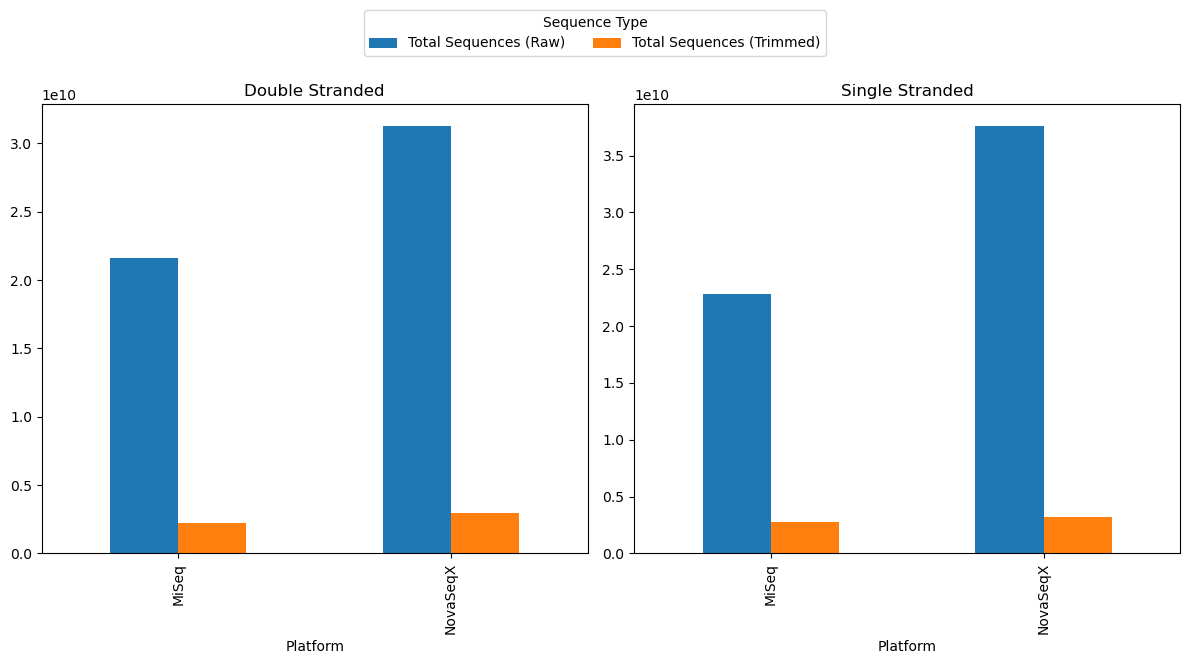

In [79]:
# Calculate mean values for each platform and each sequencing type
raw_sum_double = double_df.groupby('Platform')['fastqc_raw__Total Sequences'].sum()

trimmed_sum_double = double_df.groupby('Platform')['fastqc_trimmed__Total Sequences'].sum()

raw_sum_single = single_df.groupby('Platform')['fastqc_raw__Total Sequences'].sum()

trimmed_sum_single = single_df.groupby('Platform')['fastqc_trimmed__Total Sequences'].sum()

# Combine data into a DataFrame for easier plotting
combined_sums_double = pd.DataFrame({
    'Total Sequences (Raw)': raw_sum_double,
    'Total Sequences (Trimmed)': trimmed_sum_double
})

# Combine data into a DataFrame for easier plotting
combined_sums_single = pd.DataFrame({
    'Total Sequences (Raw)': raw_sum_single,
    'Total Sequences (Trimmed)': trimmed_sum_single
})

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
combined_sums_double.plot(kind='bar', ax=ax[0], title="Double Stranded", legend=False)
combined_sums_single.plot(kind='bar', ax=ax[1], title="Single Stranded", legend=False)

handles, labels = ax[1].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 1.01), ncol=2, title="Sequence Type")

plt.tight_layout()
plt.show()

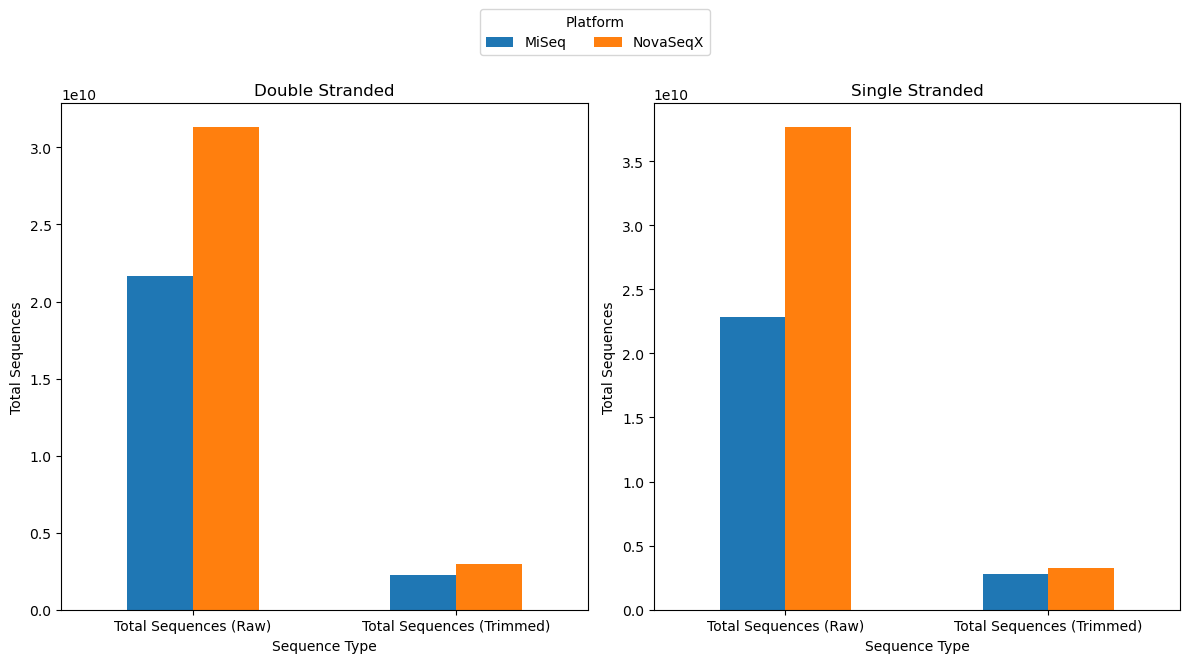

In [80]:

# Calculate mean values for each platform and each sequencing type
raw_sum_double = double_df.groupby('Platform')['fastqc_raw__Total Sequences'].sum()
trimmed_sum_double = double_df.groupby('Platform')['fastqc_trimmed__Total Sequences'].sum()

raw_sum_single = single_df.groupby('Platform')['fastqc_raw__Total Sequences'].sum()
trimmed_sum_single = single_df.groupby('Platform')['fastqc_trimmed__Total Sequences'].sum()

# Combine data into a DataFrame for easier plotting
combined_sums_double = pd.DataFrame({
    'Total Sequences (Raw)': raw_sum_double,
    'Total Sequences (Trimmed)': trimmed_sum_double
}).reset_index().melt(id_vars='Platform', var_name='Sequence Type', value_name='Total Sequences')

combined_sums_single = pd.DataFrame({
    'Total Sequences (Raw)': raw_sum_single,
    'Total Sequences (Trimmed)': trimmed_sum_single
}).reset_index().melt(id_vars='Platform', var_name='Sequence Type', value_name='Total Sequences')

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Plot for Double Stranded
combined_sums_double.pivot(index='Sequence Type', columns='Platform', values='Total Sequences').plot(kind='bar', ax=ax[0], rot=0, legend=False)
ax[0].set_title("Double Stranded")
ax[0].set_ylabel("Total Sequences")

# Plot for Single Stranded
combined_sums_single.pivot(index='Sequence Type', columns='Platform', values='Total Sequences').plot(kind='bar', ax=ax[1], rot=0, legend=False)
ax[1].set_title("Single Stranded")
ax[1].set_ylabel("Total Sequences")

# Adding legend
handles, labels = ax[1].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 1.01), ncol=2, title="Platform")

plt.tight_layout()
plt.show()

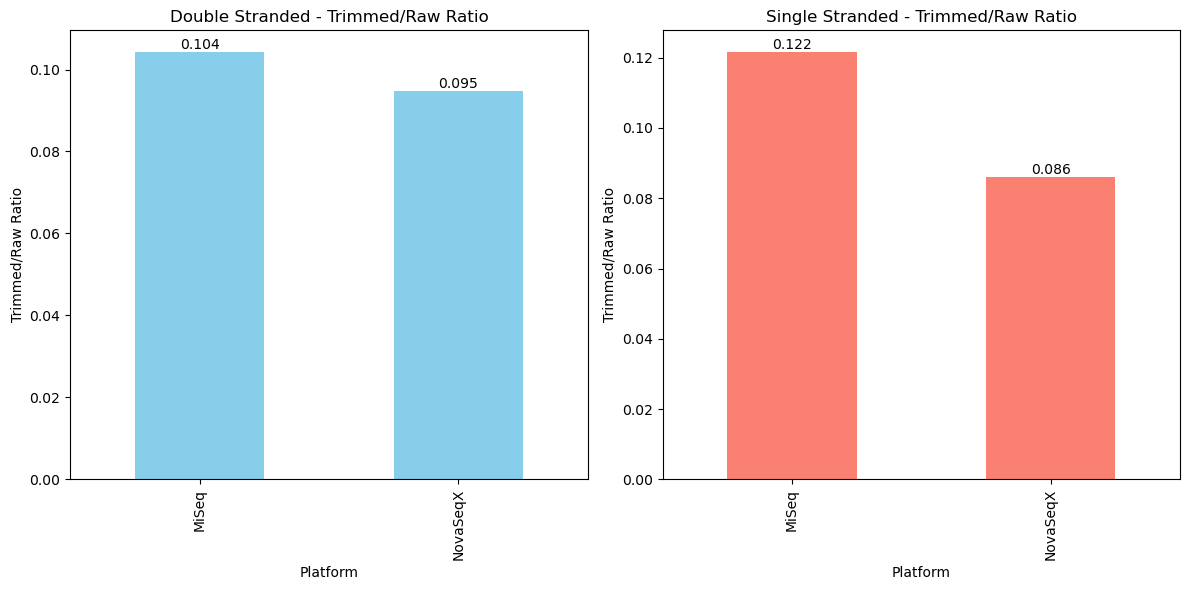

In [98]:
# Calculate the ratio of trimmed to raw sequences
ratio_double = (trimmed_sum_double / raw_sum_double).reset_index(name='Trimmed/Raw Ratio')
ratio_single = (trimmed_sum_single / raw_sum_single).reset_index(name='Trimmed/Raw Ratio')

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Plot for Double Stranded ratios
ratio_double.plot(kind='bar', x='Platform', y='Trimmed/Raw Ratio', ax=ax[0], color='skyblue', legend=False)
ax[0].set_title("Double Stranded - Trimmed/Raw Ratio")
ax[0].set_ylabel("Trimmed/Raw Ratio")
ax[0].set_xlabel("Platform")

# Annotate the bars with the ratio values
for i, value in enumerate(ratio_double['Trimmed/Raw Ratio']):
    ax[0].text(i, value, f"{value:.3f}", ha='center', va='bottom')

# Plot for Single Stranded ratios
ratio_single.plot(kind='bar', x='Platform', y='Trimmed/Raw Ratio', ax=ax[1], color='salmon', legend=False)
ax[1].set_title("Single Stranded - Trimmed/Raw Ratio")
ax[1].set_ylabel("Trimmed/Raw Ratio")
ax[1].set_xlabel("Platform")

# Annotate the bars with the ratio values
for i, value in enumerate(ratio_single['Trimmed/Raw Ratio']):
    ax[1].text(i, value, f"{value:.3f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()


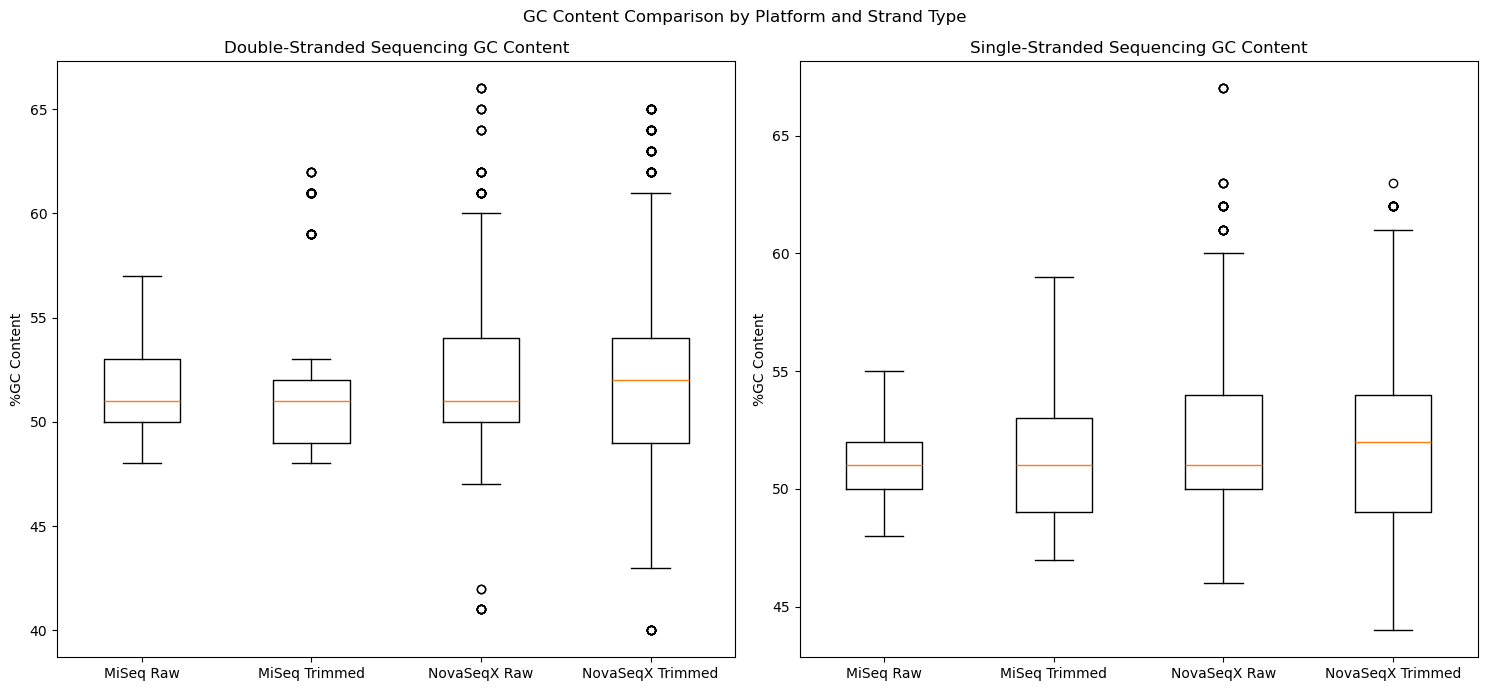

In [83]:
def make_boxplots(data, data_types, platforms, title, ax):
    gc_data = []
    labels = []

    for platform in platforms:
        for data_type in data_types:
            gc_content = data[data['Platform'] == platform][data_type].dropna()
            gc_data.append(gc_content)
            labels.append(f'{platform} {"Raw" if "raw" in data_type else "Trimmed"}')
    
    ax.boxplot(gc_data, tick_labels=labels)
    ax.set_title(title)
    ax.set_ylabel('%GC Content')

# Set up the plot
fig, axs = plt.subplots(1, 2, figsize=(15, 7))

# Platforms
platforms = [sequencer_1, sequencer_2]

describe_cols = [r"fastqc_raw__%GC", r"fastqc_trimmed__%GC"]

# Plot GC content for double-stranded and single-stranded sequencing
make_boxplots(double_df, describe_cols, platforms, 'Double-Stranded Sequencing GC Content', axs[0])
make_boxplots(single_df, describe_cols, platforms, 'Single-Stranded Sequencing GC Content', axs[1])

# Display the plot
plt.suptitle('GC Content Comparison by Platform and Strand Type')
plt.tight_layout()
plt.show()

    

c:\Users\glj523\AppData\Local\miniconda3\envs\db_web_app\Lib\site-packages\pandas\plotting\_matplotlib\core.py:822: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  labels = axis.get_majorticklabels() + axis.get_minorticklabels()
c:\Users\glj523\AppData\Local\miniconda3\envs\db_web_app\Lib\site-packages\pandas\plotting\_matplotlib\core.py:822: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  labels = axis.get_majorticklabels() + axis.get_minorticklabels()


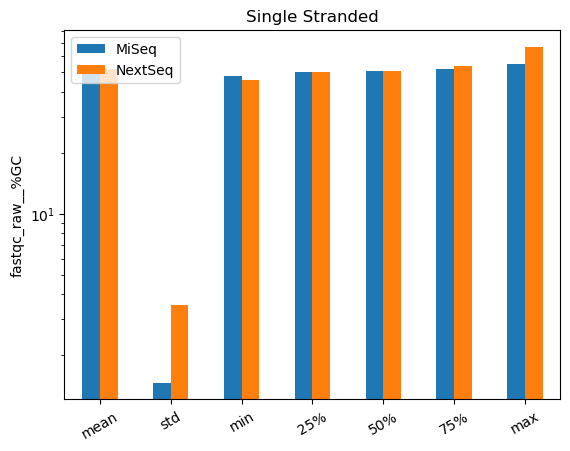

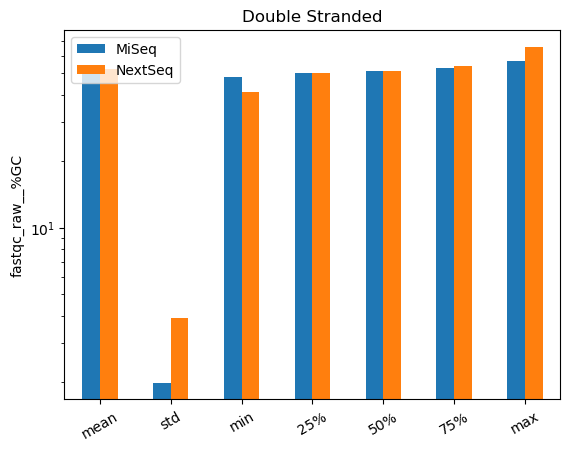

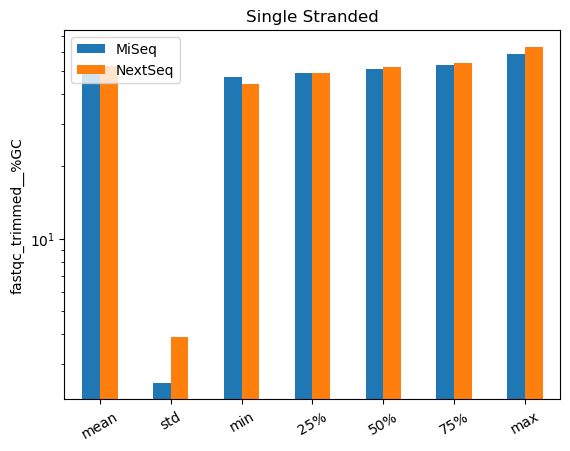

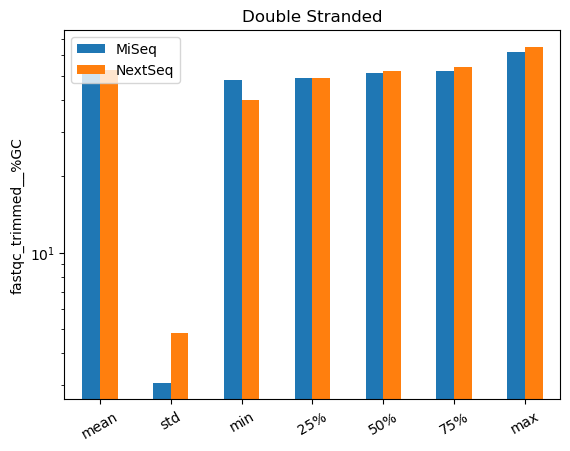

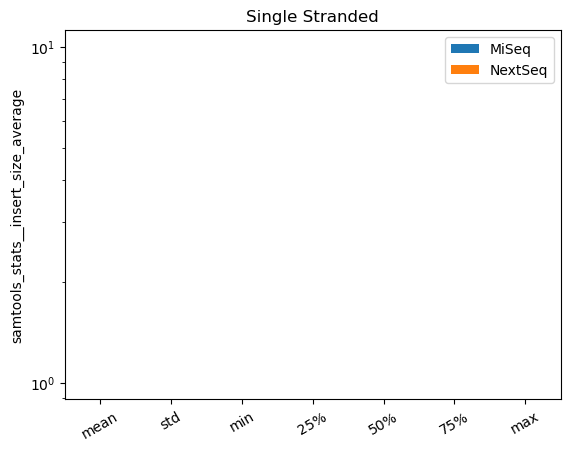

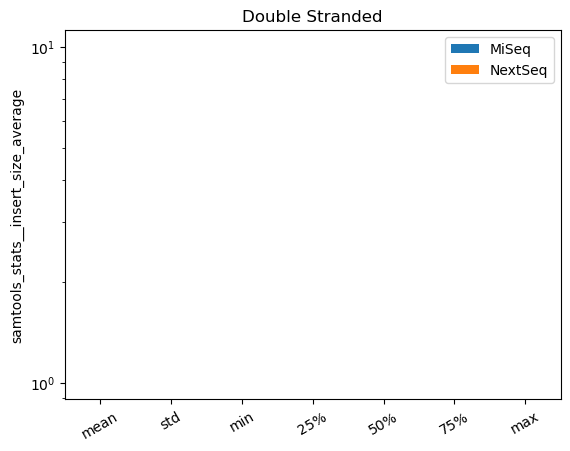

In [82]:
def make_describe_plot(col, logy, data, include_count=False):
    for k, v in data.items():
        
        if include_count:
            data = {k: v[col].describe() for k, v in v.items()}
            
        else:
            data = {k: v[col].describe().iloc[1:] for k, v in v.items()}

        res = pd.DataFrame(data)
  
        res.plot(kind="bar", rot=30, logy=logy, title=k, ylabel=col)


data = {"Single Stranded": {"MiSeq": datasets[1]["df"],
                            "NextSeq": datasets[3]["df"]},
        "Double Stranded": {"MiSeq": datasets[0]["df"],
                            "NextSeq": datasets[2]["df"]}
        }

datasets = [
    data_template(sequencer_1, "Double", ds_ms_qc),
    data_template(sequencer_1, "Single", ss_ms_qc),
    data_template(sequencer_2, "Double", ds_nx_qc),
    data_template(sequencer_2, "Single", ss_nx_qc),
]

for cols in describe_cols:

        make_describe_plot(cols, True, data, include_count=False)